
 Entrenando Random Forest para QQQ (Optimización Mejorada)...

 Resultados QQQ Mejorado:
Train Precision: 0.8128
Test Precision: 0.5278
Train Accuracy: 0.7716
Test Accuracy: 0.4352
Train ROC AUC: 0.7702
Test ROC AUC: 0.4619
Cumulative Return: -0.0314
 Modelo guardado en ../models/Random_Forest_QQQ.pkl


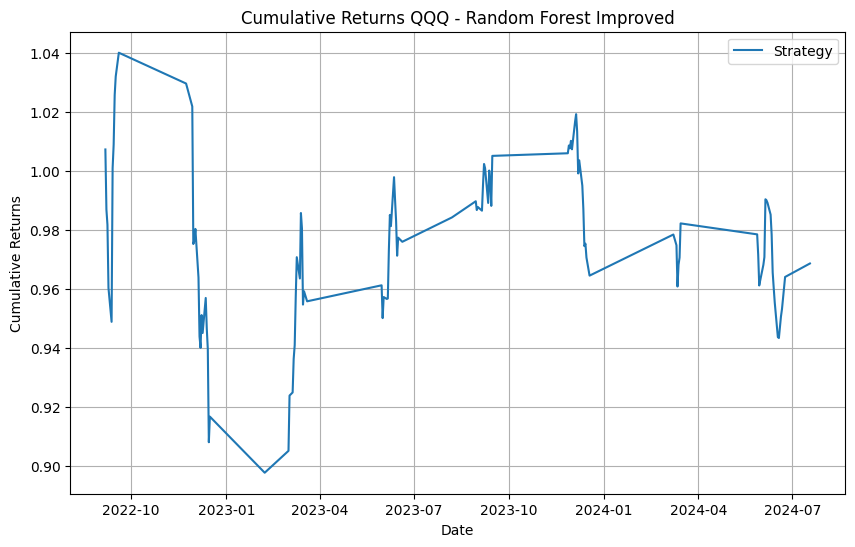


 Entrenando Random Forest para SPY (Optimización Mejorada)...

 Resultados SPY Mejorado:
Train Precision: 0.6967
Test Precision: 0.5588
Train Accuracy: 0.6629
Test Accuracy: 0.4554
Train ROC AUC: 0.6646
Test ROC AUC: 0.4866
Cumulative Return: -0.1105
 Modelo guardado en ../models/Random_Forest_SPY.pkl


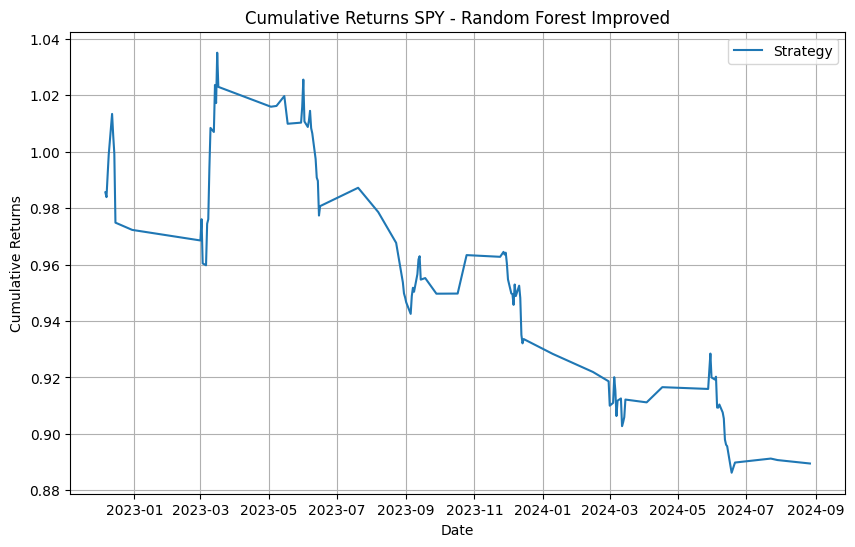

In [1]:
# ===== LIBRERÍAS =====
import sys
sys.path.append(r"C:\Users\pmate\Downloads\Pset3\Pset3\src")

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from modeling_utils import train_and_evaluate_model, save_model, plot_cumulative_returns

# ===== PATHS =====
path_QQQ = "../data/CLEAN/qqq_to_train.csv"
path_SPY = "../data/CLEAN/spy_to_train.csv"
save_path_QQQ = "../models/Random_Forest_QQQ.pkl"
save_path_SPY = "../models/Random_Forest_SPY.pkl"

# ===== CARGAR DATOS =====
data_QQQ = pd.read_csv(path_QQQ, index_col=0, parse_dates=True)
data_SPY = pd.read_csv(path_SPY, index_col=0, parse_dates=True)

returns_QQQ = data_QQQ['daily_return']
X_QQQ = data_QQQ.drop(columns=["target", "daily_return"])
y_QQQ = data_QQQ["target"]

returns_SPY = data_SPY['daily_return']
X_SPY = data_SPY.drop(columns=["target", "daily_return"])
y_SPY = data_SPY["target"]

# ===== ESCALAR =====
scaler_QQQ = StandardScaler()
X_QQQ_scaled = scaler_QQQ.fit_transform(X_QQQ)

scaler_SPY = StandardScaler()
X_SPY_scaled = scaler_SPY.fit_transform(X_SPY)

# ===== MODELO Random Forest Mejorado =====
rf_model_qqq = RandomForestClassifier(
    n_estimators=300,           # Más árboles
    max_depth=5,                # Árboles más pequeños
    min_samples_leaf=30,        # Hojas más grandes
    max_features='sqrt',        # Columnas al azar en splits
    class_weight='balanced',    # Balancear clases
    random_state=42,
    n_jobs=-1,
    verbose=0
)

# ===== ENTRENAR Y VALIDAR QQQ =====
print("\n Entrenando Random Forest para QQQ (Optimización Mejorada)...")
model_QQQ, metrics_QQQ, X_train_QQQ, X_test_QQQ, y_train_QQQ, y_test_QQQ, returns_test_QQQ = train_and_evaluate_model(
    model=rf_model_qqq,
    X=X_QQQ_scaled,
    y=y_QQQ,
    returns=returns_QQQ
)

# Mostrar métricas
print("\n Resultados QQQ Mejorado:")
for metric, value in metrics_QQQ.items():
    print(f"{metric}: {value:.4f}")

# Guardar modelo
save_model(model_QQQ, save_path_QQQ)

# Graficar retornos
plot_cumulative_returns(y_test_QQQ, model_QQQ.predict(X_test_QQQ), returns_test_QQQ, title="Cumulative Returns QQQ - Random Forest Improved")

# ===== MODELO Random Forest Mejorado para SPY =====
rf_model_spy = RandomForestClassifier(
    n_estimators=300,
    max_depth=4,               # Más conservador aún para SPY
    min_samples_leaf=50,       # Hojas grandes para SPY
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

# ===== ENTRENAR Y VALIDAR SPY =====
print("\n Entrenando Random Forest para SPY (Optimización Mejorada)...")
model_SPY, metrics_SPY, X_train_SPY, X_test_SPY, y_train_SPY, y_test_SPY, returns_test_SPY = train_and_evaluate_model(
    model=rf_model_spy,
    X=X_SPY_scaled,
    y=y_SPY,
    returns=returns_SPY
)

# Mostrar métricas
print("\n Resultados SPY Mejorado:")
for metric, value in metrics_SPY.items():
    print(f"{metric}: {value:.4f}")

# Guardar modelo
save_model(model_SPY, save_path_SPY)

# Graficar retornos
plot_cumulative_returns(y_test_SPY, model_SPY.predict(X_test_SPY), returns_test_SPY, title="Cumulative Returns SPY - Random Forest Improved")
